In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Load dataset
df = pd.read_csv("/content/daily-demand-series.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort by date
df = df.sort_values("date")

# Set date as index
df.set_index("date", inplace=True)

print("Dataset Shape:", df.shape)
display(df.head())
display(df.tail())

Dataset Shape: (30, 3)


,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


,demand,marketing_event,holiday
date,,,
2026-06-26,161,1,0
2026-06-27,174,1,0
2026-06-28,158,0,1
2026-06-29,143,0,0
2026-06-30,146,0,0


In [ ]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30 entries, 2026-06-01 to 2026-06-30
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   demand           30 non-null     int64
 1   marketing_event  30 non-null     int64
 2   holiday          30 non-null     int64
dtypes: int64(3)
memory usage: 960.0 bytes
None

Missing Values:
demand             0
marketing_event    0
holiday            0
dtype: int64

Summary Statistics:


,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


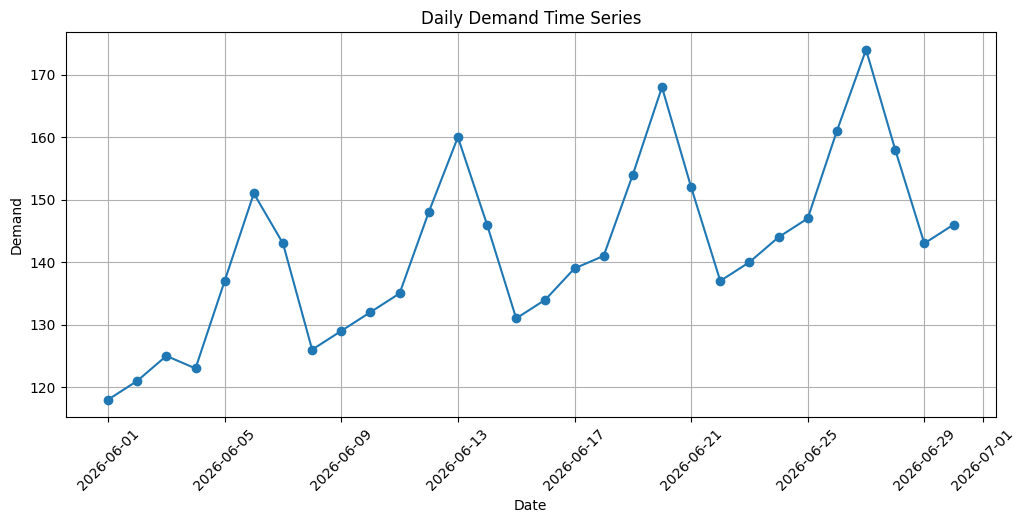

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["demand"], marker="o")

plt.title("Daily Demand Time Series")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

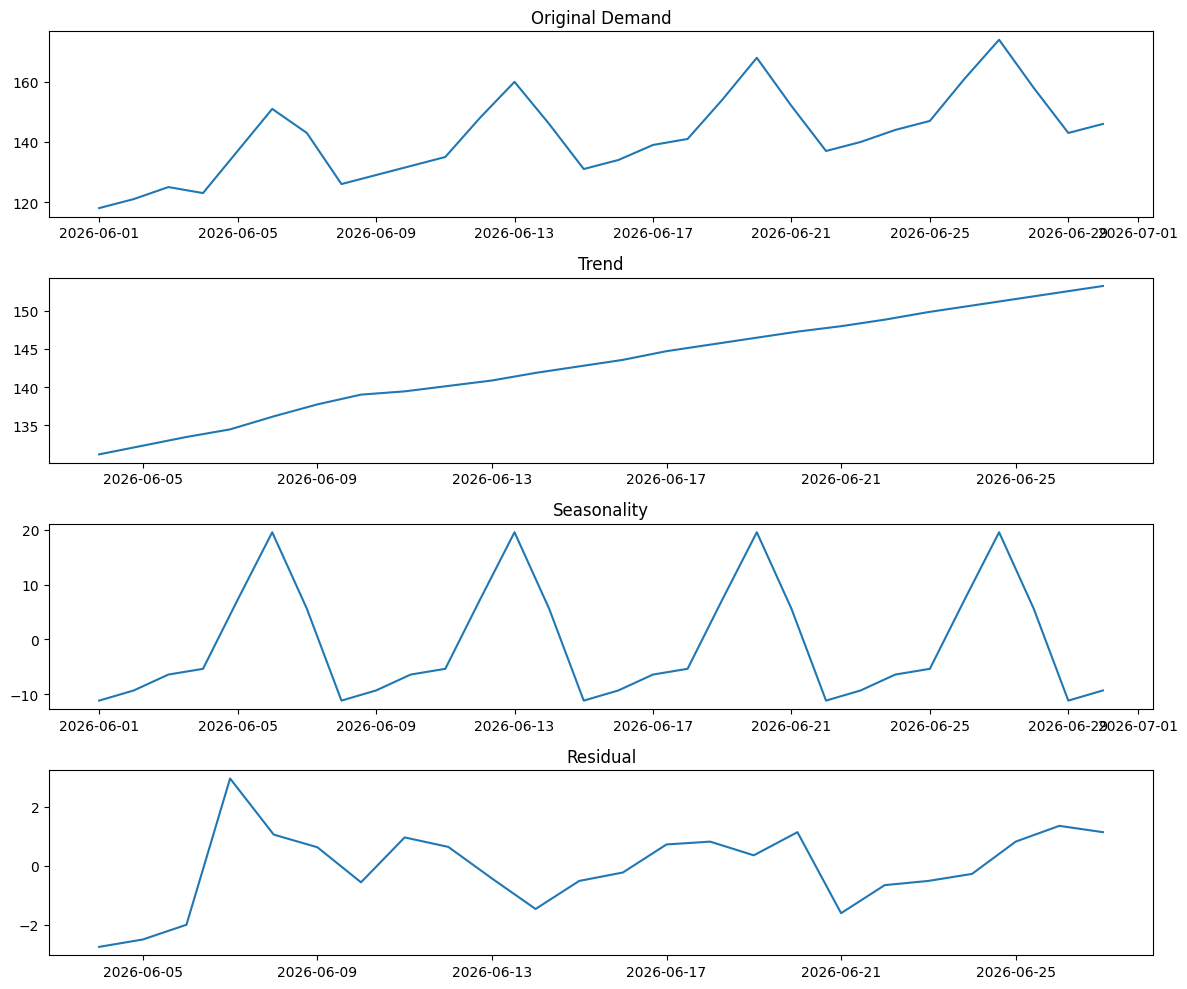

In [ ]:
# Time-Series Decomposition

decomposition = seasonal_decompose(
    df["demand"],
    model="additive",
    period=7
)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(df["demand"])
plt.title("Original Demand")

plt.subplot(4, 1, 2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4, 1, 3)
plt.plot(seasonal)
plt.title("Seasonality")

plt.subplot(4, 1, 4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

In [ ]:
# Augmented Dickey-Fuller (ADF) Test

result = adfuller(df["demand"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Result: The time series is stationary.")
else:
    print("Result: The time series is not stationary.")

ADF Statistic: -0.9038698873856339
p-value: 0.7866953368372341
Result: The time series is not stationary.


/tmp/ipykernel_848/1150825775.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df["demand"].dropna())


In [ ]:
# Train-Test Split

train_size = int(len(df) * 0.8)

train = df["demand"].iloc[:train_size]
test = df["demand"].iloc[train_size:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

print("\nTraining Period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting Period:")
print(test.index.min(), "to", test.index.max())

Training Data: 24
Testing Data: 6

Training Period:
2026-06-01 00:00:00 to 2026-06-24 00:00:00

Testing Period:
2026-06-25 00:00:00 to 2026-06-30 00:00:00


In [ ]:
# ARIMA Model

model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   24
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -82.216
Date:                Sat, 19 Sep 2026   AIC                            170.433
Time:                        15:13:37   BIC                            173.839
Sample:                    06-01-2026   HQIC                           171.289
                         - 06-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1460      0.380     -0.384      0.701      -0.891       0.599
ma.L1          0.8065      0.182      4.429      0.000       0.450       1.163
sigma2        71.9221     25.311      2.842      0.0

In [ ]:
# Generate Forecast

forecast = model_fit.forecast(steps=len(test))

print("Forecasted Demand:")
display(forecast)

Forecasted Demand:


,predicted_mean
2026-06-25,145.071592
2026-06-26,144.915111
2026-06-27,144.937962
2026-06-28,144.934625
2026-06-29,144.935112
2026-06-30,144.935041


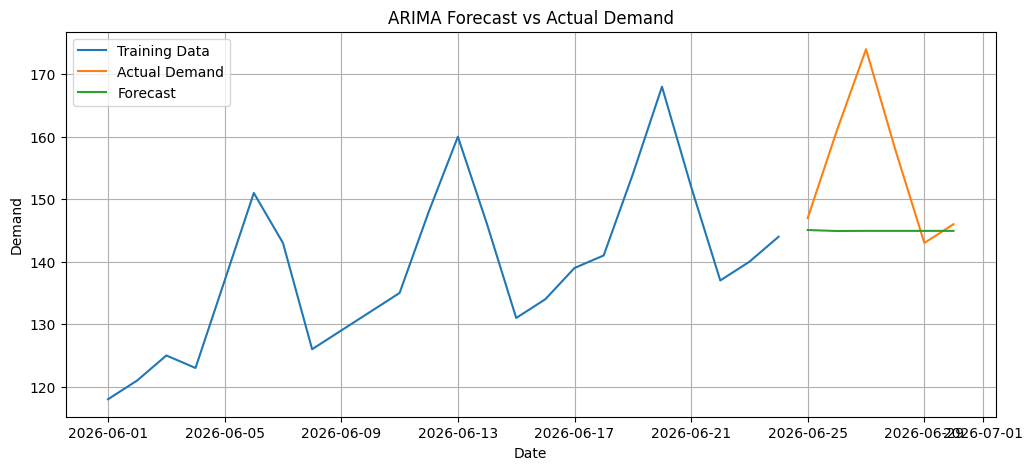

In [ ]:
# Actual vs Predicted Demand

plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Demand")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Model Evaluation

rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

RMSE: 14.62
MAPE: 6.39 %


In [ ]:
# Future Demand Forecast

future_steps = 7

future_forecast = model_fit.forecast(steps=future_steps)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

future_forecast = pd.Series(
    future_forecast.values,
    index=future_dates
)

print("Next 7 Days Demand Forecast:")
display(future_forecast.to_frame(name="Forecasted Demand"))

Next 7 Days Demand Forecast:


,Forecasted Demand
2026-07-01,145.071592
2026-07-02,144.915111
2026-07-03,144.937962
2026-07-04,144.934625
2026-07-05,144.935112
2026-07-06,144.935041
2026-07-07,144.935051


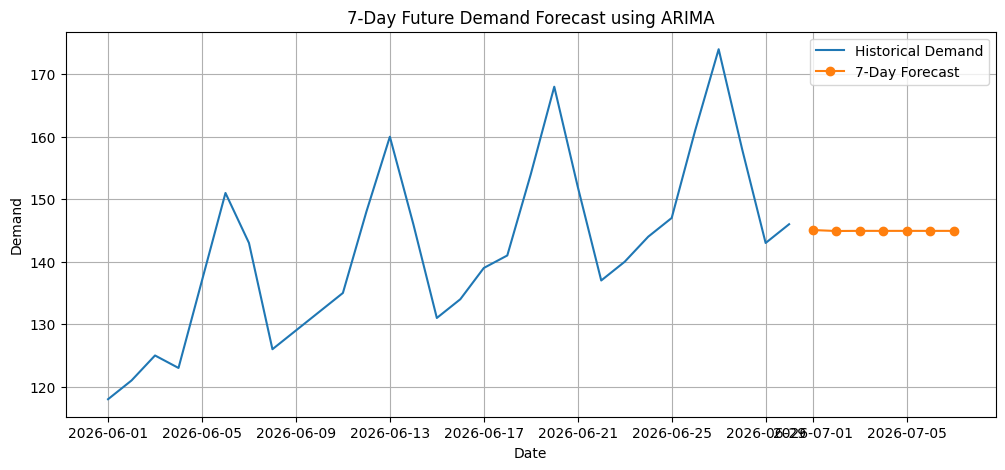

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["demand"], label="Historical Demand")
plt.plot(
    future_forecast.index,
    future_forecast,
    marker="o",
    label="7-Day Forecast"
)

plt.title("7-Day Future Demand Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

# Final Findings - Task 05

## 1. Time-Series Analysis
The daily demand dataset was analyzed using time-series forecasting techniques. The date column was converted into datetime format and used as the time-series index.

## 2. Time-Series Decomposition
The demand series was decomposed into trend, seasonal, and residual components using additive decomposition with a period of 7 days.

## 3. Stationarity Test
The Augmented Dickey-Fuller (ADF) test was performed to check stationarity.

The ADF test produced a p-value of approximately 0.7867, which is greater than 0.05. Therefore, the demand series was considered non-stationary.

## 4. ARIMA Model
An ARIMA(1,1,1) model was trained using 80% of the dataset. The remaining 20% was used as testing data.

## 5. Forecast Evaluation
The model was evaluated using RMSE and MAPE.

- RMSE: 14.62
- MAPE: 6.39%

These metrics were used to measure the difference between actual and forecasted demand.

## 6. Future Forecast
The trained ARIMA model was used to generate a 7-day future demand forecast.

## Conclusion
This analysis demonstrates a complete time-series forecasting workflow including data preparation, visualization, decomposition, stationarity testing, ARIMA modelling, forecasting, model evaluation, and future demand prediction.

# Data Science Research Capstone

## Daily Demand Forecasting Using ARIMA Time-Series Modeling

### Research Question
How effectively can an ARIMA model forecast future daily demand based on historical demand patterns?

### Objective
The objective of this project is to analyze historical daily demand patterns and develop an ARIMA-based forecasting model to predict future demand.

### Methodology
The project includes data preprocessing, exploratory data analysis, time-series decomposition, stationarity testing using the Augmented Dickey-Fuller (ADF) test, ARIMA modeling, forecasting, and model evaluation using RMSE and MAPE.

## 5. Dataset Description

The dataset contains daily demand observations along with additional information related to marketing events and holidays.

The main variables used in this research are:

| Variable | Description |
|---|---|
| date | Date of the demand observation |
| demand | Daily demand value |
| marketing_event | Indicates whether a marketing event occurred |
| holiday | Indicates whether the day was a holiday |

The `demand` variable is used as the target variable for time-series forecasting. The date variable is converted into datetime format and used as the time-series index.

## 6. Data Preparation

The dataset was loaded using Pandas and the date column was converted into datetime format. The observations were sorted chronologically and the date column was set as the index.

The demand series was then used for time-series analysis and forecasting.

## 7. Exploratory Data Analysis

The historical demand values were visualized using a time-series line plot. This visualization helps identify changes and patterns in demand over time.

Time-series decomposition was also performed to separate the observed demand into:

- Trend
- Seasonality
- Residual component

An additive decomposition with a 7-day period was used to examine weekly patterns in the demand series.

## 8. Stationarity Analysis

The Augmented Dickey-Fuller (ADF) test was used to determine whether the demand series was stationary.

The obtained p-value was approximately 0.7867, which is greater than the significance level of 0.05. Therefore, the original demand series was considered non-stationary.

Differencing was therefore incorporated into the ARIMA model.

## 9. ARIMA Modeling

The dataset was divided into training and testing portions. Approximately 80% of the observations were used for training and the remaining 20% were reserved for testing.

An ARIMA(1,1,1) model was fitted to the training data.

The ARIMA model consists of:

- AR (p) = 1
- Differencing (d) = 1
- MA (q) = 1

The fitted model was then used to generate forecasts for the testing period and future demand observations.

## 10. Results

The ARIMA model was evaluated on the testing dataset using Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE).

The obtained results were:

| Evaluation Metric | Result |
|---|---:|
| RMSE | 14.62 |
| MAPE | 6.39% |

The model was also used to generate a 7-day future demand forecast based on the historical demand observations.

## 11. Results Discussion

The RMSE value of 14.62 represents the magnitude of prediction errors in the same units as the demand variable. A lower RMSE indicates smaller prediction errors.

The MAPE value was 6.39%, indicating the average absolute percentage difference between the actual and forecasted demand values on the testing data.

The comparison between actual and forecasted demand was visualized to examine how closely the ARIMA model followed the observed demand values.

The future forecast provides an estimate of demand for the next seven days and demonstrates how the developed time-series model can be used for short-term demand forecasting.

## 12. Practical Applications

Demand forecasting can support several practical activities, including:

- Inventory and stock planning
- Resource allocation
- Workforce planning
- Supply chain management
- Short-term operational planning

Forecasting historical demand patterns can help organizations make more informed decisions about future resource requirements.

## 13. Limitations

This study has several limitations.

First, the analysis is based on a relatively small daily demand dataset, which may limit the generalizability of the findings.

Second, the forecasting model primarily uses historical demand values. Although the dataset contains `marketing_event` and `holiday` variables, these external factors were not incorporated as explanatory variables in the ARIMA model.

Third, ARIMA is a statistical time-series model and may not capture complex non-linear relationships that could be present in larger and more complex datasets.

## 14. Future Work

Future research could improve the forecasting approach by:

- Using a larger historical dataset.
- Incorporating holidays and marketing events as external predictors.
- Comparing ARIMA with SARIMA, Prophet, and machine-learning models.
- Performing systematic hyperparameter selection.
- Evaluating the model over multiple time periods.
- Exploring ensemble forecasting approaches.

## 15. Conclusion

This research presented a complete time-series forecasting workflow for daily demand prediction.

The analysis included data preparation, exploratory visualization, time-series decomposition, stationarity testing using the Augmented Dickey-Fuller test, ARIMA modeling, forecasting, and model evaluation.

The ARIMA(1,1,1) model achieved an RMSE of 14.62 and a MAPE of 6.39% on the testing data. A 7-day future demand forecast was also generated.

Overall, the project demonstrates how time-series forecasting techniques can be applied to historical demand data to generate short-term demand predictions and support data-driven planning.

## 16. References

1. Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. *Time Series Analysis: Forecasting and Control*.
2. Hyndman, R. J., & Athanasopoulos, G. *Forecasting: Principles and Practice*.
3. Python Documentation – Pandas, NumPy, Matplotlib, and Statsmodels.
4. Statsmodels Documentation – ARIMA and time-series analysis.